## Pequena introdução

Com o inicio do desenvolvimento do processamento de dados sismicos, um grande problema se agrava, que é a gravação continua e de longo prazo dos sinais sismicos 

Uma rede sismica, ou ate mesmo uma unica estação operando continuamente com alta frequencia de amostragem, produz uma quantidade enorme de dados, que muitas vezes é dificil de armaenar e analisar localmente ou ate em grande centros de gravaçoes

Essa situação fez que com que os simologos inventarem a aquisição de dados acionada por gatilho (TRIGGED  seismic data acquisition)

No modo acionado por gatilho : 
 - A estação continua processando todos os sinais em tempo real( ou quase)
 - Mas os dados nao sao sarmazendos continuamente

Um software de processamento - chamado algoritmo de trigger- detecta sinais sismicos tipos (terremotos, exploseoes, etc) dentro de um ruido constante

Quando um evento é detectado: 
 A gravação começa
 E para quando ao algoritmo dclara que o evento terminou]



### Onde eles sao usados ? 
Normalmente usado em aplicações de movimento fraco (weak-motion), onde se tenta registrar o maximo possivel de eventos sismicos

É praticamente um padrao em:
 - Gravadores sismicos portateis 
 - Softwares de processamento em tempo real

Tambem pode ser utl em aplicações de movemnto forte, exceto quando o interesse esta apenas nos terremotos mais intenos

### Como o STA/LTA funciona?
O algoritmo processa sinais sismicos filtrados usando duas janeals moveis:
 - STA (short time average)
 - LTA (long time average)

-> O STA mede a amplitude 'instantanea'
-> O LTA mede a média do ruido atual

Passo: 
1) calcula - se o valor absoluto de cada amostra
2) Calcula-se a média nas duas janelas
3) Calcula-se a razao STA/LTA
4) Compara-se com um threshold definido pelo usuario

Se a razao ultrapassar o limite do theresh -> trigger ligado


ATENÇÃO : Um canal ativado nao significa necessariamente que a rede inteira começa a gravar 

Redes sismicas usam mecanimos de votação:
 - Quantos canais precisam estar ativados 
 - Quais canais?

Para simplificar, o texto assume apenas um canal


### Quando um evento termina?
O canal desativa quando a razao cai abaixo do outro parametro:
 - Threshold de detrigger

Esse valor deve ser menor(ou raramente igual)  ao threshold do trigger

### PEM e PET
Alem dos dados durante o trigger ativo :
 - PEM (pre event memory): dados antes do trigger
 - PET (post event time) : dados depois do trigger

Isso garante que o evento nao seja cortado

#### Exemplo
Trigger thresh = 10
detrigger thresh = 2

O evento começa quando a razao ultrapassa 10 e termina quando fica <2

O arquivo final contem:
 - Tudo sobre o evento
 - Parte do ruido antes

### Visoes em nivel de pesquisa:
1 - LSA/LTA é um detector de mudança de regime:
     Detecta mudança estatistica abrupta na energia do sinal

2 - Ele assume que o ruido é quase estacionáro
    Se o ruido variar lentamente, o LTA acompanha
    Mas se o ruido mudar rapido (vento forte, chuva, atividade humana), ela pode falhar.

3 - Ele é extremamente leve computacionalmente
    Complexidade O(N)

In [ ]:
!pip install obspy

  Using cached obspy-1.4.2-cp311-cp311-win_amd64.whl.metadata (4.0 kB)
  Using cached numpy-2.4.2-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached lxml-6.0.2-cp311-cp311-win_amd64.whl.metadata (3.7 kB)
  Using cached SQLAlchemy-1.4.54-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp311-cp311-win_amd64.whl.metadata (116 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.1.1-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached charset_normalizer-3.4.4-cp311-cp311-win_amd64.whl.metadata (38 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 k

: 

In [1]:
from obspy.signal.trigger import plot_trigger
from obspy.signal.trigger import classic_sta_lta
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from obspy.signal.trigger import recursive_sta_lta
from obspy.signal.trigger import carl_sta_trig
from obspy.signal.trigger import delayed_sta_lta
from obspy.signal.trigger import z_detect


In [2]:
## Choose an event and read the waveform data
#Choose an event
origin_time = UTCDateTime("2015-08-11T16:22:15.200000")

#Coordinates and the magnitude of the event
eq_lon = 123.202
eq_lat = -8.624
eq_dep = 171.9
eq_mag = 3.9

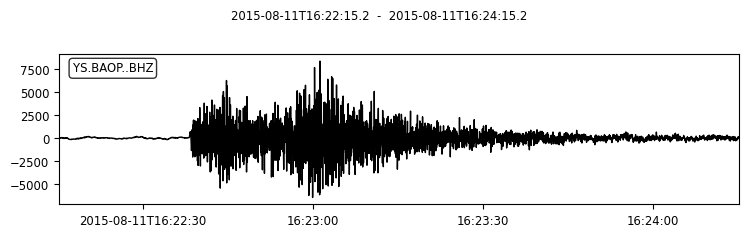

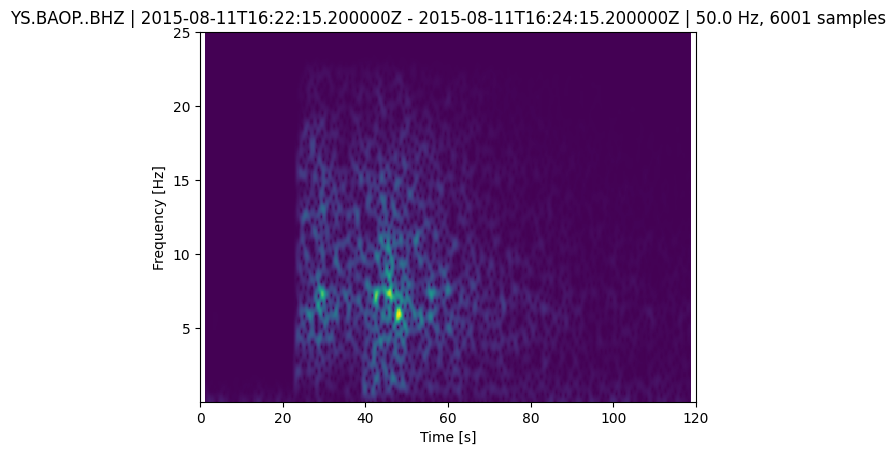

[None]

In [4]:
#Choose a station and get the waveform

#Iris is one of those providers
client = Client('IRIS')
#input station information

#Network
net = 'YS'
#Station
sta = 'BAOP'
#Location
loc = ''
#channel
cha = 'BHZ'

#starttime
stt = origin_time
#endtime
edt = origin_time + 120

#Get the waveform data from client
st = client.get_waveforms(net, sta, loc, cha, stt, edt)
st.plot()
st.spectrogram()

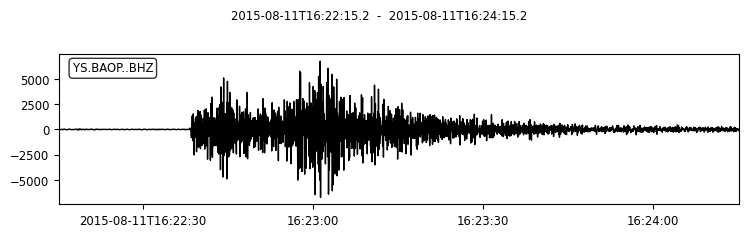

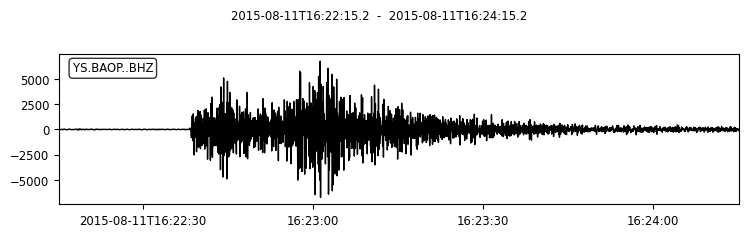

In [5]:
#Filter data
#copy the data raw
st2 = st.copy()
#appply the bandpass between 1 and 10 Hz, in order to filter the noise
st2.filter("bandpass",freqmin=1.0, freqmax=10.0)
st2.plot()

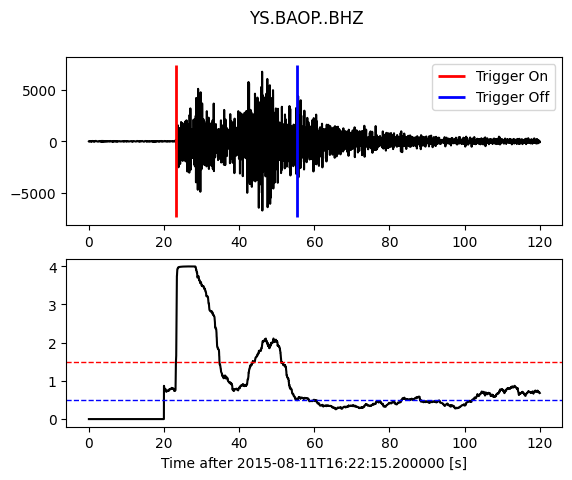

In [6]:
#Triggering example
df = st2[0].stats.sampling_rate
#set the sta = 5 seconds, lta = 20s
cft = classic_sta_lta(st2[0].data, int(5 * df), int(20 * df))
#plot the trigger function
plot_trigger(st2[0], cft, 1.5, 0.5)

## Selecao da duracao da janela STA

A janela de curta duração (sta) mede o valor instantaneo de um sinal sismico 

De modo geral, a duração da STA deve ser maior que alguns periodos do sinal sismico tipicamente esperado

Se a STA for muito curta, a media do sinal sismico nao funcionará corretamente. A STA deixara de ser uma medida da media do sinal e passara a aser influenciada por periodos individuais do sinal.

Por outro lado, a duração da STA deve ser menor que os menores eventos que se espera capturar.

A STA pode ser considerada como um filtro de um sinal

Quanto menor a duração escolhida : 
 - Maior a sensibilidade do trigger a terrmotos locais de curta duraçao
 - Em comparação com terremetos distantes de longa duração e baixa frequencia

Quanto maior a duração da STA:
 - Menor a sensibilidade a terremotos locais curtos

Portanto, ao alterar a duração do STA , é possivel priorizar a captura de eventos distantes ou locais

Valores tipicos:
 - Eventos regionais: STA entre 1 e 2
 - Terremotos locais: STA entre 0.3 e 0.5


**Algumas visoes :**

    1) STA precisa cobrir varios ciclos na onda
     
    2) STa nao pode ser maior que o evento : Se o evento dura 0.5s o sta nao pode 
        ter 2s, pois, a janela engole o evento inteiro.

    3) Regra fisica: Alguns periodos < STA < Duracao do evento

    4) Sta funciona como filtro : STA é basicamente uma media movel (filtro passa baixa)
        - STA curta -> Passa variaçoes rapidas -> sensivel a eventos curtos
        - STA longa -> suaviza -> privilegia eventos longos

    5) Mudando sta priorizamos enventos locais ou distantes
        - Eventos locais : alta frequencia, curta duração, energia concentrada
        - Eventos distantes : baixa freq, longa duração e energia espalhada

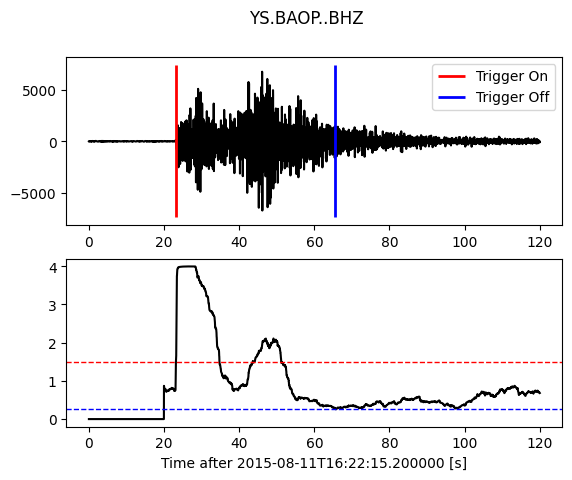

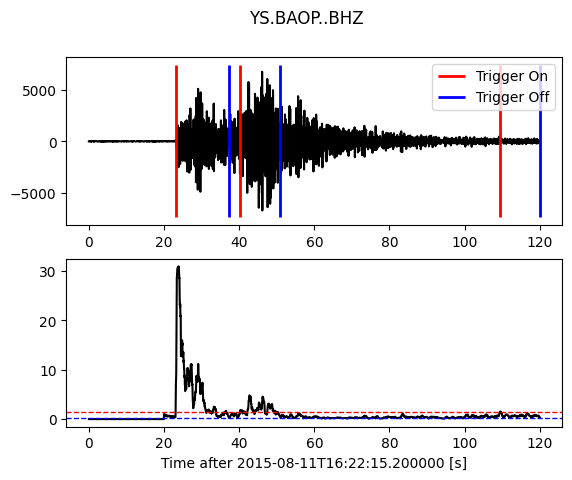

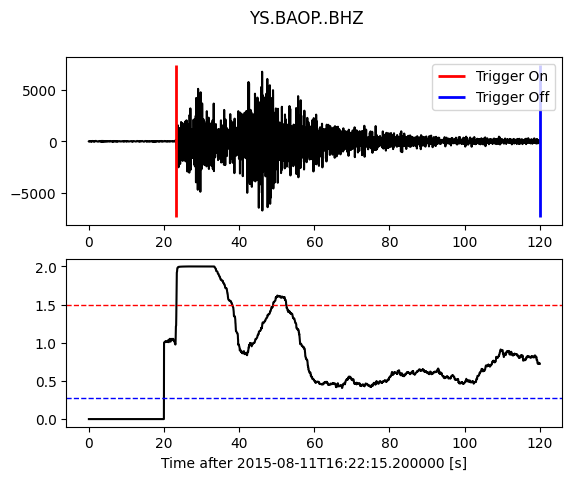

In [7]:
df = st2[0].stats.sampling_rate
#Only set different short-time average window (STA) durations
#sta = 5s

cft = classic_sta_lta(st2[0].data, int(5 * df), int(20 * df))
plot_trigger(st2[0], cft, 1.5, 0.27)
#sta = 5s, represents a smaller value
cft = classic_sta_lta(st2[0].data, int(0.65 * df), int(20 * df))
plot_trigger(st2[0], cft, 1.5, 0.27)
#sta = 10s, represents a larger value
cft = classic_sta_lta(st2[0].data, int(10 * df), int(20 * df))
plot_trigger(st2[0], cft, 1.5, 0.27)

## Selecao da duracao da janela LTA (long-term-average)

A janela LTA mede a amplitude média do ruido sismico

Ela deve durar mais que alguns 'periodos' das flutuações irregulares tipicas do ruido sismico.

Ao modificar a duração do LTA, pode-se tornar a gravação mais ou menos sensivel a eventos regionais na faixa de onda Pn, entre aprox 200 a 1500km de distancia epicentral

Esses eventos tipicamente apresentam ondas Pn emergentes de baixa amplitude como primeira chegada

-> Se a LTA for curta:
    - O valor da LTA se ajusta gradualmente ao aumento lento da amplitude dessas ondas emergentes.
    - Assim, tanto o STA quando LTA aumentam
    - A razao STA/LTA permanece baixa
    - Isso reduz a sensibilidade do trigger a esses eventos

-> Se a LTA for longa:
    - O valor da LTA não é rapidamente influenciado pela aumento gradual do sinal
    - A razao STA/LTA cresce mais
    - Isso aumenta a sensiblidade a terremotos emergentes
    - Permite que ondas Sg/Lg acionam a gravação 

Uma LTA mais curta é usada quando:
    - Deseja-se evitar que eventos regionais emergentes disparem o trigger
    - Há ruido antropogenico variavel rapidamente

Uma LTA mais longa pode ser usada para:
    - Eventos regionais distantes
    - Longos tempos S-P
    - Ondas P emergentes

Ele basicamente responde : Qual é o nivel médio do ambiente agora, medindo nivel de ruido de fundo

-> Porque ela precisa ser longa:
    Porque ruido sismico é irregular. Pode variar : vento, atividade humana, microtremores oceanicos, trafego

-> LTA muito curta: ela se adapta rápido demais


-> O problema das ondas emergentes: 
    Eventos distantes geralmente comçam com ondas PN: baixa amplitude, crescimento gradual, sem pico abrupto

    Se a LTA for curta : O sinal começa a crecer lentamente -> Trigger nao despara 

Intuição simples :
 - LTA curta : Sistema adaptativo rapido
 - LTA longa : sistema conservador

**Visoes da parada :**
    1) LTa controla sensibilidade a eventos emergentes
        Eventos emergentes = crescimento lento
        - LTA curto -> suprime
        - LTA longa -> amplifica
    
    2)LTA longa aumenta robustez contra ruído gradual
        Se houver ruido que cresce lentamente(ex: vento aumentando)
        - LTA longa mantem estabilidade
        - Evita normalizar esse ruido rapidamente

    3) LTA curta é util em espaço urbano

    4) No contexto de edge comuting : LTA longa -. mais memoria, mais historico armazenado, mais operações


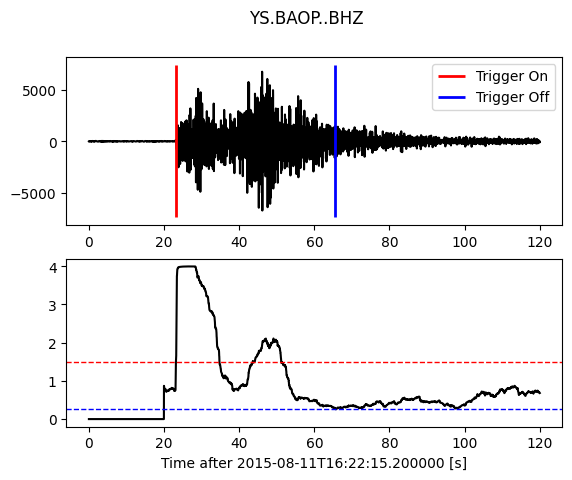

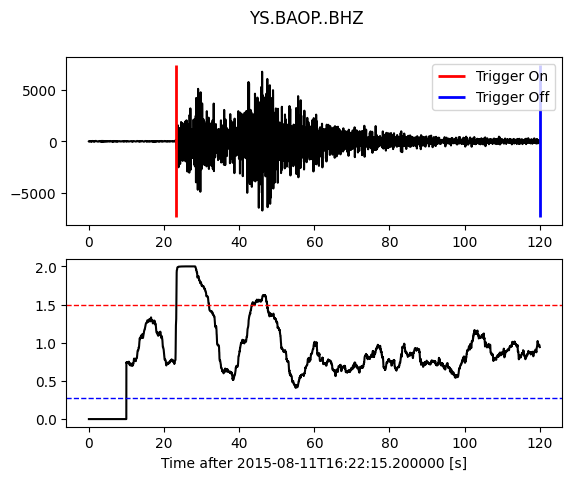

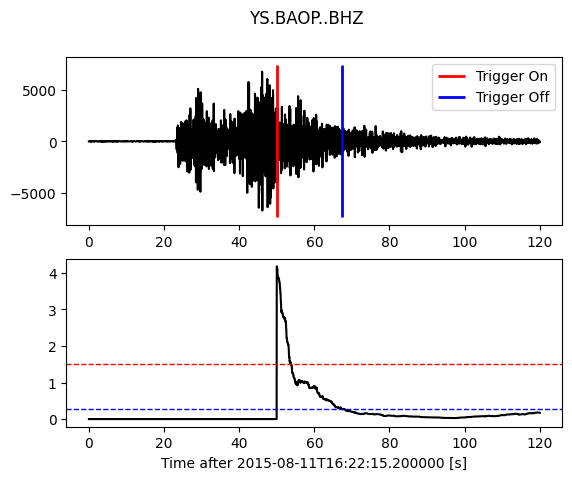

In [8]:
# only set different long-time average window (STA) durations
# lta=20 seconds
cft = classic_sta_lta(st2[0].data, int(5 * df), int(20 * df))
plot_trigger(st2[0], cft, 1.5, 0.27)
# lta=10 seconds, represents a smaller value
cft = classic_sta_lta(st2[0].data, int(5 * df), int(10 * df))
plot_trigger(st2[0], cft, 1.5, 0.27)
# lta=50 seconds, represents a larger value
cft = classic_sta_lta(st2[0].data, int(5 * df), int(50 * df))
plot_trigger(st2[0], cft, 1.5, 0.27)

### Selecao do nivel de treshold do trigger STA/LTA

O nivel de treshold do trigger STA/LTA é o que mais determina quais eventos serao gravados e quais nao serao

Quanto maior o valor configurado:
 - Mais terremotos deixarão de ser registrados
 - Mas menos falsos triggers ocorrerão

Quanto menor o valor : 
 - A estação será mais sensivel
 - Mais eventos serão gravados
 - Porém haverá mais falsos triggers

Valor ideal depende: 
  - Das condições de ruido do local
  - Da tolerancia a falsos registros

Nao apenas da amplitude, mas tambem o tipo de ruido sismico influencia a escolhja do threshold


Se o ruido for estaticamente estacionário (menos irregular):
    - Pode-se usar threshold menor

Se o ruido for muito irregular:
    - São necessários thresholds maiores

Ruido estacionario != ruido irregular 
estacionario : Microtremor constante, ruido oceanico, ambiente rural silencioso -> ruido previsivel -> Thresh pode ser baixo

irregular : Caminhao passando, consturção civil, maquina ligando e desligando -> thresh maior

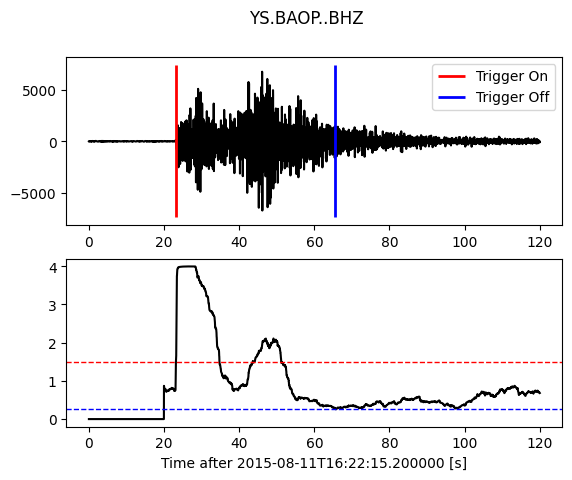

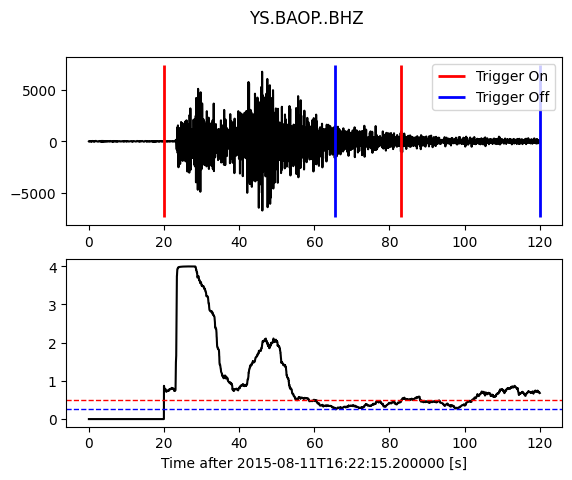

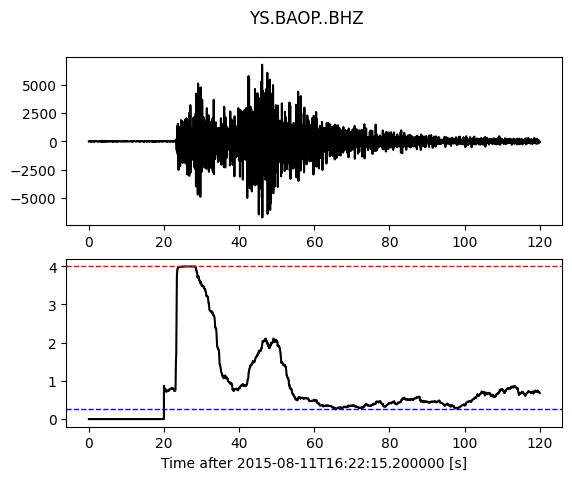

In [9]:
cft = classic_sta_lta(st2[0].data, int(5 * df), int(20 * df))
# only set different STA/LTA trigger threshold levels
# STA/LTA trigger threshold = 1.5
plot_trigger(st2[0], cft, 1.5, 0.27)
# STA/LTA trigger threshold = 0.5, represents a small trigger threshold value
plot_trigger(st2[0], cft, 0.5, 0.27)
# STA/LTA trigger threshold = 4, represents a large trigger threshold value
plot_trigger(st2[0], cft, 4, 0.27)

### Seleção do nivel de threshold de detrigger do STA/LTA

O nivel de detrigger determinada quando a gravação será encerrada

Para incluir o maximo possivel das ondas de coda(parte final do evento), é necessario um valor baixo

Se a duração da coda for usada para determinar magnitude, essa configuração é claramente necessária, no entando UM BAIXO VALOR É PERIGOSO.

Pode causa registros muito longos ou até intermináveis, por exemplo, se um aumento repentino no ruido sismico impedir que a razao STA/LTA caia abaixo do threshold de detrigger.

Por outro lado, se nao houver interesse nas ondas de coda, um valor mais alto permite economia significativa de memoria e/ou de transmissao de dados

As ondas de coda de terremotos distantes podem ser muito longas

**relembrando conceitos :** 
-> Onda P(primaria) : primeira a chegar, mais rapida, compressional (vai e volta), geralmente menor amplitude, pode ser emergente (Cresce devagar) -> Vp > Vs -> Ela marca o inicio do evento

-> Onda S(secundária) : Chega depois de P, mais lenta, movimento transversal, maior amplitude, dispara o trigger -> As> Ap ->

-> Ondas superficiais(Lg, Raleight, Love):  Chegam depois da S, podem ter grande amplitude, longa duração

-> Coda : Depois das ondas principais, ainda existe energia:  reflexoes, esopelhamento, reverbeio geologico -> Isso é chamado de CODA

 


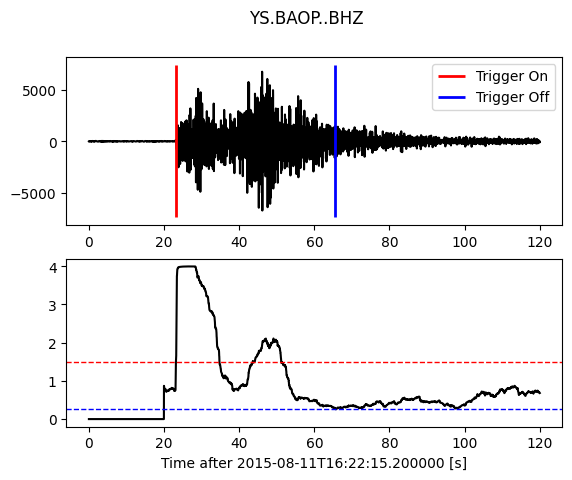

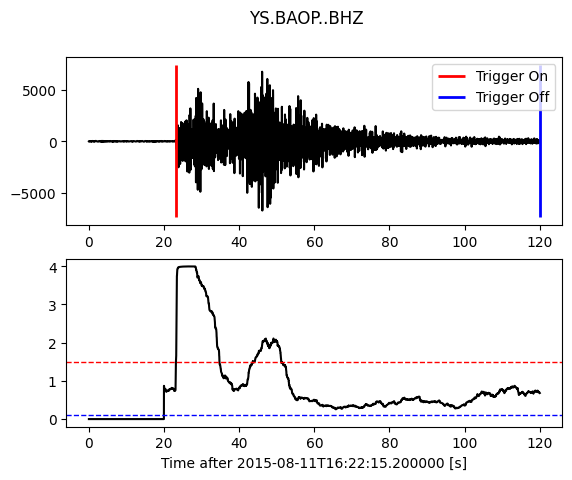

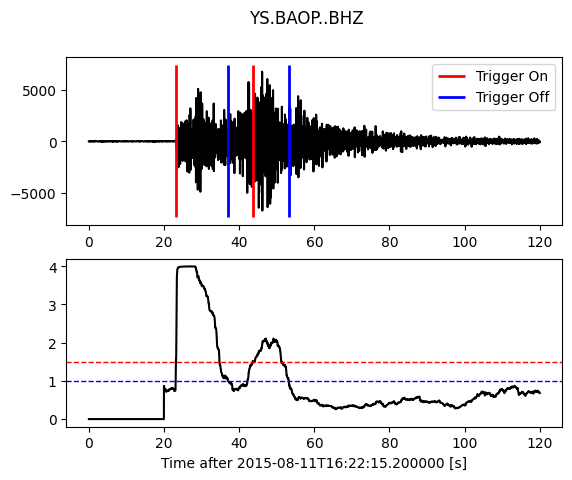

In [10]:
cft = classic_sta_lta(st2[0].data, int(5 * df), int(20 * df))
# only set different STA/LTA detrigger threshold levels
# STA/LTA trigger threshold = 1.5
plot_trigger(st2[0], cft, 1.5, 0.27)
# STA/LTA detrigger threshold = 0.1, represents a small trigger threshold value
plot_trigger(st2[0], cft, 1.5, 0.1)
# STA/LTA detrigger threshold = 1, represents a large trigger threshold value
plot_trigger(st2[0], cft, 1.5, 1)

## Sta/Lta : Detecção classica em sistemas sismicos

Obetivos :
- Entender a intuição fisica do metodo
- Formalizar matematicamente
- Implementar manualmente e com obspy
- Aplicar a dados reais do SCEDEC
- Visualizar e interpretar resultado
- Discutir limitações e ecolhja de parametros
- conectar com modelos de ml